# Phase 5 – Model Evaluation

## Logistic Regression Evaluation

Student: Hasaan Rashidi  
Course: SOFE4620 Machine Learning and Data Mining

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [8]:
df = pd.read_csv("../data/raw/creditcard.csv")

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

log_model = LogisticRegression(random_state=42, max_iter=5000)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

### Purpose of Evaluation

After training the Logistic Regression model, its performance must be evaluated on the test set. Because the credit card fraud dataset is highly imbalanced, accuracy alone is not enough to judge performance. Metrics such as precision, recall, and F1-score provide a more meaningful assessment of how well the model identifies fraudulent transactions.

In [9]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[56851    13]
 [   34    64]]


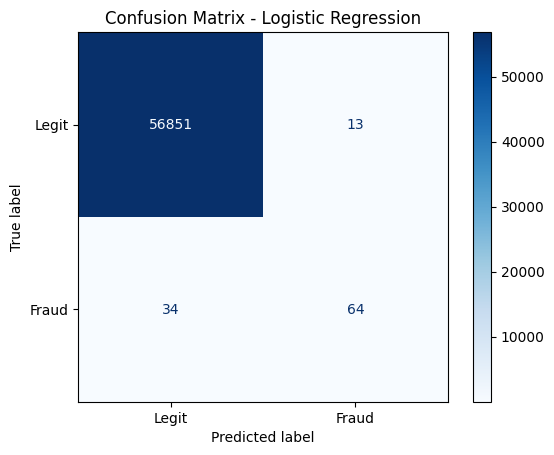

In [10]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legit", "Fraud"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [11]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.9991748885221726
Precision: 0.8311688311688312
Recall: 0.6530612244897959
F1-score: 0.7314285714285714


In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.65      0.73        98

    accuracy                           1.00     56962
   macro avg       0.92      0.83      0.87     56962
weighted avg       1.00      1.00      1.00     56962



### Meaning of the Evaluation Metrics

- **Accuracy** measures the overall proportion of correct predictions.
- **Precision** measures how many transactions predicted as fraud were actually fraud.
- **Recall** measures how many actual fraudulent transactions were correctly detected.
- **F1-score** balances precision and recall.

In fraud detection, recall is especially important because false negatives mean fraudulent transactions were missed.

### Interpretation

The Logistic Regression model achieved an accuracy of 99.92%, a precision of 83.12%, a recall of 65.31%, and an F1-score of 73.14%. Although the accuracy is very high, this is expected because the dataset is heavily imbalanced and most transactions are legitimate.

The confusion matrix shows that the model correctly identified 64 fraudulent transactions while missing 34 fraud cases. It also incorrectly labeled 13 legitimate transactions as fraudulent. These results suggest that Logistic Regression provides a strong baseline model, especially in terms of precision, but there is still room for improvement in recall since missing fraudulent transactions is costly in real-world fraud detection.